# Bike Sharing Demand Prediction

## Data Loading

In [1]:
import sys
print(sys.executable)

/Users/sanyukta/.pyenv/versions/3.11.9/bin/python


In [2]:
!conda install -y scikit-learn scipy numpy

zsh:1: command not found: conda


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso

sns.set_style('whitegrid')
pd.set_option('display.width', 120)

train = pd.read_csv('bike_train.csv')
test = pd.read_csv('bike_test.csv')


In [4]:
test_datetime_raw = test['datetime'].copy()

train['dt'] = pd.to_datetime(train['datetime'], format='mixed')
test['dt'] = pd.to_datetime(test['datetime'], format='mixed')

In [5]:
print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (10450, 13)
Test shape : (2613, 10)


## Q1. Dataset size, missing values, and feature types

In [6]:
print("Training shape:", train.shape)
print("Test shape:", test.shape)

print("\nMissing values (train):")
print(train.isna().sum())

print("\nMissing values (test):")
print(test.isna().sum())

print("\nTraining data types:")
print(train.dtypes)


Training shape: (10450, 13)
Test shape: (2613, 10)

Missing values (train):
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dt            0
dtype: int64

Missing values (test):
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
dt            0
dtype: int64

Training data types:
datetime                 str
season                 int64
holiday                int64
workingday             int64
weather                int64
temp                 float64
atemp                float64
humidity               int64
windspeed            float64
casual                 int64
registered             int64
count                  int64
dt            datetime64[us]
dtype: object


**Answer (Q1):** The training set contains 10,450 hourly observations across
12 columns; the test set contains 2,613 observations across 9 columns (it
naturally omits casual, registered, and count, which are only known
after the fact). Neither file has any missing values, so no imputation is
required. datetime is stored as a string and needs to be parsed; season,
holiday, workingday, and weather are integer-coded categories rather
than true numeric quantities; temp, atemp, humidity, and windspeed
are continuous numeric features; count (and its components casual +
registered) is the target.


## Q2. Visualize relationships between key features and count

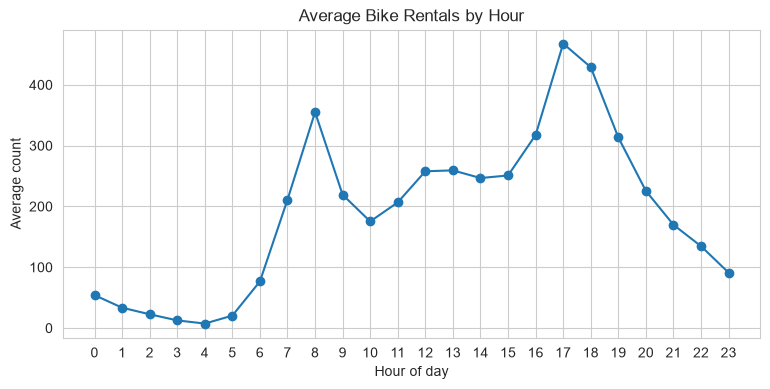

In [7]:
hourly_count = train.groupby(train['dt'].dt.hour)['count'].mean()

plt.figure(figsize=(9, 4))
plt.plot(hourly_count.index, hourly_count.values, marker='o')
plt.xlabel('Hour of day')
plt.ylabel('Average count')
plt.title('Average Bike Rentals by Hour')
plt.xticks(range(24))
plt.grid(True)
plt.show()


In [8]:
# The single most important interaction in this dataset: hour-of-day
# behaves completely differently on working days (commute peaks) vs.
# non-working days (a broad midday hump).
tmp = train.copy()
tmp['hour'] = tmp['dt'].dt.hour
hour_work = tmp.groupby(['hour', 'workingday'])['count'].mean().unstack()



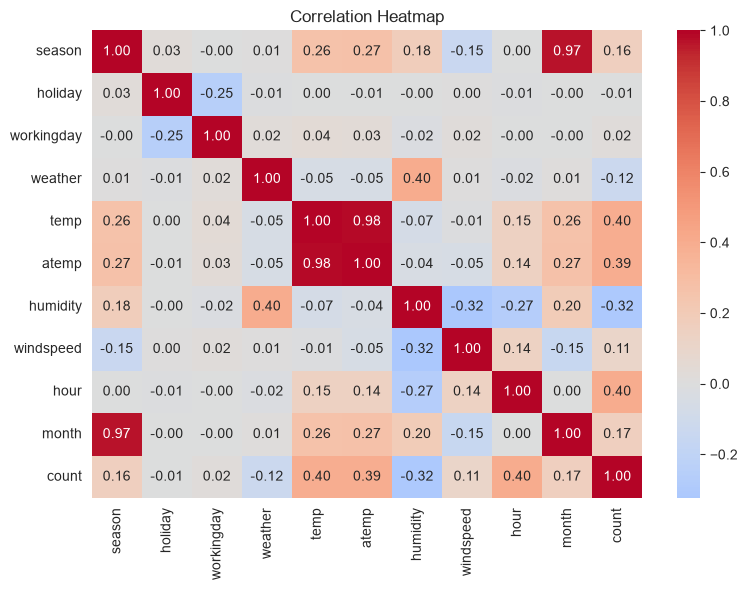

In [9]:
tmp['month'] = tmp['dt'].dt.month
corr_cols = ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
             'humidity', 'windspeed', 'hour', 'month', 'count']
corr = tmp[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


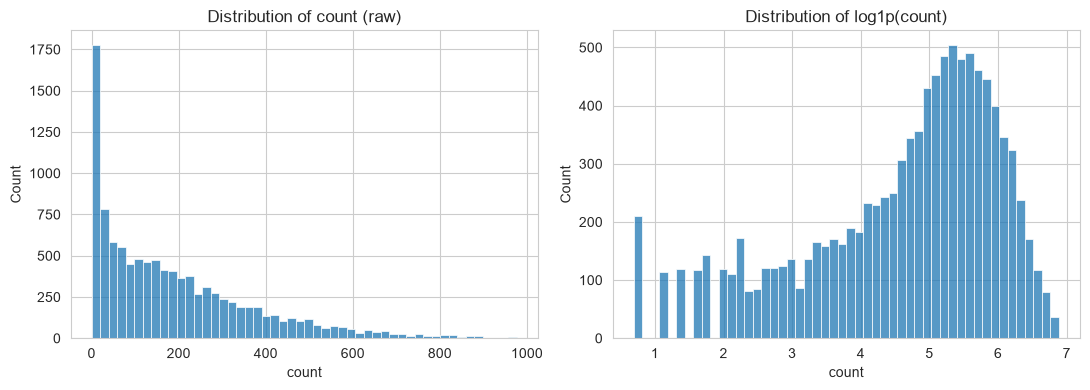

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(train['count'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of count (raw)')
sns.histplot(np.log1p(train['count']), bins=50, ax=axes[1])
axes[1].set_title('Distribution of log1p(count)')
plt.tight_layout()
plt.show()


**Answer (Q2):** Count is mainly driven by hour. Working days show two commute peaks (8 AM and 5–6 PM), while non-working days have one broad midday peak, showing an interaction between hour and workingday. Temp/atemp are positively related to demand, while humidity is negatively related. There is also a clear seasonal pattern. Count is right-skewed, whereas log1p(count) is more symmetric, supporting the use of log1p(count) for modelling.


## Q3. Which variables are likely to be most informative?

In [11]:
numeric_cols = train.select_dtypes(include='number')
correlation = numeric_cols.corr()['count'].sort_values(ascending=False)
print(correlation)


count         1.000000
registered    0.970108
casual        0.691971
temp          0.396451
atemp         0.390642
season        0.160333
windspeed     0.105318
workingday    0.017361
holiday      -0.005615
weather      -0.124402
humidity     -0.316607
Name: count, dtype: float64


**Answer (Q3):** Hour has the strongest linear correlation with count, followed by temp/atemp, while humidity is negatively correlated. Month/season show a moderate seasonal effect. Workingday, weekday, and holiday have little linear correlation individually, but their interaction with hour makes them important. Year also has low individual correlation but reflects the growth in bike-sharing demand from 2011 to 2012.


## Q4. Feature Engineering

In [12]:
def make_features(df):
    x = df.copy()
    dt = x.pop('dt')

    x['year'] = dt.dt.year
    x['month'] = dt.dt.month
    x['day'] = dt.dt.day
    x['hour'] = dt.dt.hour
    x['weekday'] = dt.dt.dayofweek
    x['doy'] = dt.dt.dayofyear          # day-of-year: smooth intra-year trend

    # --- Interaction terms -------------------------------------------------
    # A linear model can only add hour's effect and workingday's effect
    # separately. Concatenating them into one categorical column lets the
    # model learn a SEPARATE hourly curve for working vs. non-working days --
    # exactly the commute-peak vs. midday-hump pattern 
    x['hour_work'] = x['hour'].astype(str) + '_' + x['workingday'].astype(str)
    # Same idea for hour x day-of-week (weekend curve differs from weekday).
    x['hour_weekday'] = x['hour'].astype(str) + '_' + x['weekday'].astype(str)
    # year_month captures the strong year-over-year ridership growth together
    # with each month's seasonal level (the service grew substantially in
    # scale from 2011 to 2012).
    x['year_month'] = x['year'].astype(str) + '_' + x['month'].astype(str)

    return x

X = make_features(train).drop(columns=['datetime', 'count', 'casual', 'registered'])
y = train['count']

print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (10450, 17)


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour,weekday,doy,hour_work,hour_weekday,year_month
0,3,0,0,1,28.70000,33.335000,79,6.003200,2012,7,15,7,6,197,7_0,7_6,2012_7
1,3,0,1,1,33.62000,37.880000,46,15.001300,2012,8,14,15,1,227,15_1,15_1,2012_8
2,1,0,0,1,10.66000,12.880000,60,15.001300,2011,2,6,6,6,37,6_0,6_6,2011_2
3,2,0,0,2,26.42506,30.566166,61,9.512288,2012,5,6,17,6,127,17_0,17_6,2012_5
4,1,0,1,1,9.84000,12.120000,56,8.998100,2012,1,9,2,0,9,2_1,2_0,2012_1


**Answer (Q4) — Feature Engineering:**

1. **Datetime:** Extracted year, month, day, hour, weekday, and day-of-year.

2. **Interactions:** Created hour_work, hour_weekday, and year_month to capture non-additive effects and improve the linear model.

3. **Categorical Encoding:** One-hot encoded categorical features without assuming numerical order.

4. **Polynomial Features:** Applied degree-2/3 polynomial terms to continuous variables to capture non-linear effects.

5. **Log Target:** Trained models using log1p(count) and converted predictions back using expm1, as count is right-skewed and RMSLE is measured in log-space.


## RMSLE Function

In [13]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)  # count can never be negative
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))


## Q5. Train/Validation Split + Simple Linear Regression

In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print(X_train.shape, X_val.shape)

raw_cols = ['season', 'holiday', 'workingday', 'weather',
            'temp', 'atemp', 'humidity', 'windspeed']

# Baseline A: predict raw count directly
baseline_raw = LinearRegression().fit(X_train[raw_cols], y_train)
pred_raw = np.clip(baseline_raw.predict(X_val[raw_cols]), 0, None)
rmsle_raw = rmsle(y_val, pred_raw)

# Baseline B: predict log1p(count), invert with expm1
baseline_log = LinearRegression().fit(X_train[raw_cols], np.log1p(y_train))
pred_log = np.clip(np.expm1(baseline_log.predict(X_val[raw_cols])), 0, None)
rmsle_log = rmsle(y_val, pred_log)

print(f"Simple Linear Regression (raw target)   RMSLE: {rmsle_raw:.4f}")
print(f"Simple Linear Regression (log1p target) RMSLE: {rmsle_log:.4f}")


(8360, 17) (2090, 17)
Simple Linear Regression (raw target)   RMSLE: 1.4215
Simple Linear Regression (log1p target) RMSLE: 1.2220


**Observation (Q5):** an 80/20 train/validation split is used. A plain
Linear Regression on only the raw weather/calendar columns (no time-of-day
features at all) scores RMSLE ≈ 1.42 on raw count, improving to
RMSLE ≈ 1.22 when trained on log1p(count) instead — simply because this
aligns the training loss with the evaluation metric (RMSLE). Both numbers
are still far worse than anything in Q6/Q7: this model has no way to
represent the strong time-of-day pattern found in Q2/Q3, since it doesn't
even see hour as a feature.


## Q6. Polynomial Features + Ridge / Lasso Regression

To tune alpha reliably, all models are evaluated using **5-fold cross-validation** instead of one 80/20 split. Training RMSLE is also reported for each fold to compare training and CV errors. A large gap, especially at low alpha, indicates overfitting, which we aim to avoid.


In [15]:
cat_cols = ['season', 'holiday', 'workingday', 'weather', 'year', 'month',
            'weekday', 'hour', 'hour_work', 'hour_weekday', 'year_month']

num_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'day', 'doy']

def make_pipeline(degree, alpha, model='ridge'):
    prep = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', Pipeline([
            ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
            ('scaler', StandardScaler())
        ]), num_cols)
    ])
    
    reg = Ridge(alpha=alpha) if model == 'ridge' else Lasso(alpha=alpha, max_iter=5000, tol=1e-3)
    return Pipeline([('prep', prep), ('reg', reg)])


In [16]:
def make_linear_pipeline():
    # One-hot encoding + scaling, but NO polynomial expansion -- an
    # intermediate model between the Q5 baseline and the full Q6 models.
    
    prep = ColumnTransformer([
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ])

    return Pipeline([('prep', prep), ('reg', LinearRegression())])

In [17]:
def cv_rmsle(build_model, X, y, n_splits=5, random_state=42):
    """5-fold CV. Fits on log1p(y) each fold, scores RMSLE on the ORIGINAL
    count scale. Returns (mean_train_rmsle, mean_cv_rmsle, std_cv_rmsle)."""
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    y_log_full = np.log1p(y)
    train_scores, val_scores = [], []

    for tr_idx, va_idx in kf.split(X):
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]
        y_tr_log = y_log_full.iloc[tr_idx]

        model = build_model()
        model.fit(X_tr, y_tr_log)

        pred_tr = np.clip(np.expm1(model.predict(X_tr)), 0, None)
        pred_va = np.clip(np.expm1(model.predict(X_va)), 0, None)

        train_scores.append(rmsle(y_tr, pred_tr))
        val_scores.append(rmsle(y_va, pred_va))

    return float(np.mean(train_scores)), float(np.mean(val_scores)), float(np.std(val_scores))


In [18]:
tr_lin, va_lin, sd_lin = cv_rmsle(make_linear_pipeline, X, y)

print(f"Engineered Log-Linear (one-hot, no polynomial):")
print(f"  train RMSLE = {tr_lin:.4f}   CV RMSLE = {va_lin:.4f} +/- {sd_lin:.4f}")


Engineered Log-Linear (one-hot, no polynomial):
  train RMSLE = 0.3870   CV RMSLE = 0.3986 +/- 0.0080


In [19]:
alpha_grid_ridge = [1, 3, 5, 7, 9, 12, 15, 20, 30]

def select_alpha_1se(alphas, cv_means, cv_stds):
    """One-standard-error rule (Elements of Statistical Learning): among
    alphas whose CV RMSLE is within 1 std of the best score, pick the
    LARGEST alpha -- i.e. the simplest, most-regularized model that is not
    measurably worse. This deliberately avoids picking whichever alpha
    happens to minimize CV error by a hair, which risks overfitting to the
    particular CV split."""

    best_idx = int(np.argmin(cv_means))
    threshold = cv_means[best_idx] + cv_stds[best_idx]
    candidates = [a for a, m in zip(alphas, cv_means) if m <= threshold]
    return max(candidates)

def sweep_ridge(degree):
    rows = []
    
    for a in alpha_grid_ridge:
        tr, va, sd = cv_rmsle(lambda a=a: make_pipeline(degree, a, 'ridge'), X, y)
        rows.append((a, tr, va, sd))
    return pd.DataFrame(rows, columns=['alpha', 'train_RMSLE', 'cv_RMSLE', 'cv_std'])


In [20]:
ridge2_sweep = sweep_ridge(degree=2)

print("Ridge, polynomial degree 2")
print(ridge2_sweep.to_string(index=False))

best_alpha_ridge2 = select_alpha_1se(
    ridge2_sweep['alpha'].tolist(),
    ridge2_sweep['cv_RMSLE'].tolist(),
    ridge2_sweep['cv_std'].tolist()
)
print("\nSelected alpha (1-SE rule):", best_alpha_ridge2)


Ridge, polynomial degree 2
 alpha  train_RMSLE  cv_RMSLE   cv_std
     1     0.377749  0.389506 0.008995
     3     0.378410  0.389281 0.008770
     5     0.379148  0.389426 0.008704
     7     0.379929  0.389777 0.008687
     9     0.380772  0.390278 0.008691
    12     0.382163  0.391255 0.008720
    15     0.383711  0.392473 0.008758
    20     0.386616  0.394930 0.008879
    30     0.393508  0.401171 0.009167

Selected alpha (1-SE rule): 20


In [21]:
ridge3_sweep = sweep_ridge(degree=3)

print("Ridge, polynomial degree 3")
print(ridge3_sweep.to_string(index=False))

best_alpha_ridge3 = select_alpha_1se(
    ridge3_sweep['alpha'].tolist(),
    ridge3_sweep['cv_RMSLE'].tolist(),
    ridge3_sweep['cv_std'].tolist()
)
print("\nSelected alpha (1-SE rule):", best_alpha_ridge3)


Ridge, polynomial degree 3
 alpha  train_RMSLE  cv_RMSLE   cv_std
     1     0.372083  0.385552 0.008472
     3     0.372967  0.385299 0.008481
     5     0.373906  0.385532 0.008448
     7     0.374872  0.385987 0.008492
     9     0.375854  0.386566 0.008541
    12     0.377414  0.387641 0.008603
    15     0.379093  0.388912 0.008652
    20     0.382158  0.391448 0.008796
    30     0.389248  0.397812 0.009113

Selected alpha (1-SE rule): 20


In [22]:
lasso_alpha_grid = [0.0005, 0.001, 0.002, 0.005]

def sweep_lasso(degree):
    rows = []
    for a in lasso_alpha_grid:
        tr, va, sd = cv_rmsle(lambda a=a: make_pipeline(degree, a, 'lasso'), X, y)
        rows.append((a, tr, va, sd))
    return pd.DataFrame(rows, columns=['alpha', 'train_RMSLE', 'cv_RMSLE', 'cv_std'])

lasso2_sweep = sweep_lasso(degree=2)

print("Lasso, polynomial degree 2")
print(lasso2_sweep.to_string(index=False))

lasso3_sweep = sweep_lasso(degree=3)

print("\nLasso, polynomial degree 3")
print(lasso3_sweep.to_string(index=False))


Lasso, polynomial degree 2
 alpha  train_RMSLE  cv_RMSLE   cv_std
0.0005     0.386712  0.394582 0.009599
0.0010     0.395906  0.401389 0.009555
0.0020     0.410820  0.414828 0.009373
0.0050     0.458584  0.462023 0.009071

Lasso, polynomial degree 3
 alpha  train_RMSLE  cv_RMSLE   cv_std
0.0005     0.383683  0.392163 0.009481
0.0010     0.393547  0.399256 0.009663
0.0020     0.407897  0.411979 0.009659
0.0050     0.454632  0.458158 0.009262


**Observation (Q6):** For degree-3 Ridge, CV RMSLE is lowest around alpha ≈ 3 (≈0.3853) and rises at higher alpha values, while training RMSLE keeps improving as alpha decreases, showing mild overfitting. The **1-standard-error rule** selects the more stable alpha = 20. Degree-3 performs slightly better than degree-2, while Ridge is more stable than Lasso as alpha increases.


## Q7. Model Comparison

The first two rows (Q5 raw-feature baselines) use the required 80/20 hold-out split. All subsequent models, including the no-polynomial engineered baseline, use 5-fold cross-validation, which provides a more reliable performance estimate and is used to select the final alpha and degree. Thus, CV results are the most reliable for model comparison.

In [23]:
best_ridge2_row = ridge2_sweep.loc[ridge2_sweep['alpha'] == best_alpha_ridge2].iloc[0]
best_ridge3_row = ridge3_sweep.loc[ridge3_sweep['alpha'] == best_alpha_ridge3].iloc[0]
best_lasso2_row = lasso2_sweep.loc[lasso2_sweep['cv_RMSLE'].idxmin()]
best_lasso3_row = lasso3_sweep.loc[lasso3_sweep['cv_RMSLE'].idxmin()]

comparison = pd.DataFrame({
    'Model': [
        'Simple Linear Regression, raw target (Q5, single split)',
        'Simple Linear Regression, log1p target (Q5, single split)',
        'Engineered Log-Linear, one-hot, no polynomial (5-fold CV)',
        f"Ridge, poly deg=2, alpha={best_alpha_ridge2} [1-SE] (5-fold CV)",
        f"Ridge, poly deg=3, alpha={best_alpha_ridge3} [1-SE] (5-fold CV)",
        f"Lasso, poly deg=2, alpha={best_lasso2_row['alpha']} (5-fold CV)",
        f"Lasso, poly deg=3, alpha={best_lasso3_row['alpha']} (5-fold CV)",
    ],
    'Train RMSLE': [
        rmsle_raw, rmsle_log, tr_lin,
        best_ridge2_row['train_RMSLE'], best_ridge3_row['train_RMSLE'],
        best_lasso2_row['train_RMSLE'], best_lasso3_row['train_RMSLE'],
    ],
    'Val / CV RMSLE': [
        rmsle_raw, rmsle_log, va_lin,
        best_ridge2_row['cv_RMSLE'], best_ridge3_row['cv_RMSLE'],
        best_lasso2_row['cv_RMSLE'], best_lasso3_row['cv_RMSLE'],
    ],
})
comparison['Gap (Val/CV - Train)'] = comparison['Val / CV RMSLE'] - comparison['Train RMSLE']
comparison = comparison.sort_values('Val / CV RMSLE').reset_index(drop=True)
comparison.index += 1
comparison.index.name = 'Rank'
print(comparison.to_string())

best_model_name = comparison.iloc[0]['Model']
print("\nBest model:", best_model_name)


                                                          Model  Train RMSLE  Val / CV RMSLE  Gap (Val/CV - Train)
Rank                                                                                                              
1                Ridge, poly deg=3, alpha=20 [1-SE] (5-fold CV)     0.382158        0.391448              0.009290
2                   Lasso, poly deg=3, alpha=0.0005 (5-fold CV)     0.383683        0.392163              0.008480
3                   Lasso, poly deg=2, alpha=0.0005 (5-fold CV)     0.386712        0.394582              0.007870
4                Ridge, poly deg=2, alpha=20 [1-SE] (5-fold CV)     0.386616        0.394930              0.008313
5     Engineered Log-Linear, one-hot, no polynomial (5-fold CV)     0.386974        0.398576              0.011602
6     Simple Linear Regression, log1p target (Q5, single split)     1.221970        1.221970              0.000000
7       Simple Linear Regression, raw target (Q5, single split)     1.421538    

**Interpretation (Q7):** Raw-feature linear models perform poorly (RMSLE ≈ 1.2–1.4) because they cannot capture the strong time-of-day pattern. Adding calendar and interaction features greatly improves performance, reducing CV RMSLE to ≈0.399, mainly due to hour_work and hour_weekday interactions. Polynomial weather features give a smaller further improvement, with **Ridge (degree 3, alpha = 20)** performing best at CV RMSLE ≈0.391, closely followed by Lasso (degree 3). The train/CV gap remains below ≈0.012, indicating good generalization with limited overfitting.

## Q8. Residual Plot (Best Model)

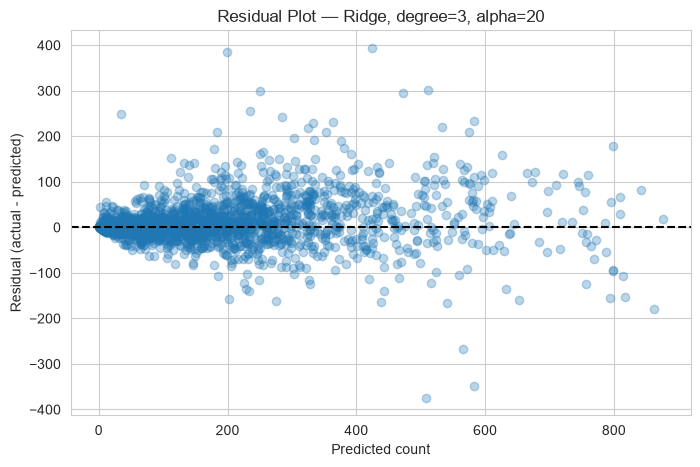

Hold-out validation RMSLE for this plot: 0.39012012114739103


In [24]:
best_degree = 3 if 'deg=3' in best_model_name else 2
best_alpha = best_alpha_ridge3 if best_degree == 3 else best_alpha_ridge2

# Refit on the Q5 train/val split (not the CV folds) purely so we have a
# single held-out set of points to plot residuals against.
best_check_model = make_pipeline(best_degree, best_alpha, 'ridge')
best_check_model.fit(X_train, np.log1p(y_train))

pred_best_val = np.clip(np.expm1(best_check_model.predict(X_val)), 0, None)
residuals = y_val - pred_best_val

plt.figure(figsize=(8, 5))
plt.scatter(pred_best_val, residuals, alpha=0.3)
plt.axhline(0, linestyle='--', color='k')
plt.xlabel('Predicted count')
plt.ylabel('Residual (actual - predicted)')
plt.title(f'Residual Plot — Ridge, degree={best_degree}, alpha={best_alpha}')
plt.show()

print("Hold-out validation RMSLE for this plot:", rmsle(y_val, pred_best_val))


**Observation (Q8):** Residuals are centered near zero but **fan out at higher predicted counts**, indicating heteroscedasticity. The model is more accurate for low-demand hours but tends to under-predict high-demand commute peaks. This reflects the limitation of a regularized linear model, which may not capture extreme combinations of conditions as well as tree-based or boosted models.

## Q9. Why does the winning model perform better?

The winning model combines three key ideas:

1. **Interaction Features:** hour_work, hour_weekday, and year_month capture non-additive time effects, providing the largest improvement over the raw baseline.
2. **Log-Target Training:** Using log1p(count) reduces target skew and aligns training with RMSLE.
3. **Polynomial Weather Features:** Degree-2/3 terms capture non-linear weather effects, while Ridge regularization controls variance from expanded and correlated features.

The **1-standard-error alpha selection** improves robustness by favouring better generalization rather than only the lowest validation error. Together, these methods reduce CV RMSLE from ≈1.2 to ≈0.39, giving roughly a **3× reduction in error**.


## Q10. Why does RMSLE penalize under-predictions more gently than RMSE?

RMSLE compares log(pred + 1) to log(actual + 1), so it measures
*relative* (multiplicative) error rather than absolute error. Predictions
have a hard floor at 0, but no upper bound — so on the log scale, an
under-prediction (e.g. predicting 10 when the truth is 100) is bounded by
how far `log(pred+1)` can fall relative to `log(actual+1)`, while an
over-prediction of the same absolute size (predicting 190 vs. 100) produces
a comparable log-difference in the opposite direction, but a *much* larger
raw error under plain RMSE. In plain RMSE terms, a large under-prediction
"looks" the same size as a large over-prediction, so RMSE penalizes both
equally in absolute terms; RMSLE instead treats them symmetrically as
*ratios*, which in practice means it is much gentler on models that
occasionally under-shoot a big demand spike than one that wildly over-shoots
a quiet hour by the same absolute amount.


## Q11. Trade-offs between model simplicity and predictive power

| | Simple linear model | Polynomial + Ridge/Lasso (this notebook) | More complex models (e.g. tree ensembles) |
|---|---|---|---|
| Interpretability | High — each coefficient has a direct meaning | Medium — polynomial/interaction terms are harder to reason about individually | Low — hard to explain a single prediction |
| Ability to fit non-linear/interaction effects | Low | Medium-High (only what is explicitly engineered) | High (learned automatically) |
| Overfitting risk | Low (few parameters) | Medium — grows with polynomial degree and number of interaction categories; controlled here via regularization + CV | Higher without careful tuning (many parameters) |
| Data/compute needs | Low | Moderate | Higher |
| Sensitivity to feature engineering choices | High (must get the linear terms right) | High (must choose the right interactions/degree) | Lower (model can discover patterns itself) |

In short: added flexibility (polynomial terms, interaction features, more
complex model families) buys predictive power at the cost of interpretability
and overfitting risk, which must be actively managed — here through Ridge
regularization, the 1-SE alpha rule, and cross-validation rather than a
single validation split.


## Q12. Why can't Linear Regression alone capture time-of-day effects effectively?

If `hour` (0-23) is fed into Linear Regression as a single numeric value,
the model can only learn one thing about it: "each additional hour changes
demand by a fixed amount, beta." Real bike demand does not behave this way —
it is low overnight, rises sharply during the morning commute, dips at
midday, rises again for the evening commute, and falls off at night; treating
`hour` as ordinal also wrongly implies that hour 23 and hour 0 are far apart
numerically when they are actually adjacent in time. One-hot encoding `hour`
fixes the ordinality problem and lets each hour have its own independent
effect, but a plain linear model still assumes that effect is the *same* on
every day type. Q2 showed that is false: the hourly curve on working days
(commute double-peak) is a fundamentally different shape from non-working
days (single midday hump). Only by explicitly building the `hour_work`
(and `hour_weekday`) interaction terms can a linear model represent this —
otherwise it is forced to average the two curves together and fit neither
well, which is exactly why the raw-feature baseline in Q7 performs so much
worse than the engineered models.


## Final Model


In [25]:
X_test = make_features(test).drop(columns=['datetime'])

final_model = make_pipeline(best_degree, best_alpha, 'ridge')
final_model.fit(X, np.log1p(y))

test_pred = np.clip(np.expm1(final_model.predict(X_test)), 0, None)
test_pred = np.round(test_pred).astype(int)  # count is inherently a whole number

submission = pd.DataFrame({
    'datetime': test_datetime_raw,
    'count_predicted': test_pred
})

submission.to_csv('submission.csv', index=False)
print(submission.head())
print("\nShape:", submission.shape)


           datetime  count_predicted
0   05-06-2012 5:00               14
1  19-03-2011 19:00              121
2   02-04-2012 6:00               55
3  13-07-2012 20:00              356
4  09-11-2011 19:00              234

Shape: (2613, 2)


## Submission Validation

In [26]:
print(submission.head())

print("\nShape:")
print(submission.shape)

print("\nColumns:")
print(submission.columns.tolist())

print("\nMissing values:")
print(submission.isna().sum())

print("\nNegative predictions:")
print((submission['count_predicted'] < 0).sum())


           datetime  count_predicted
0   05-06-2012 5:00               14
1  19-03-2011 19:00              121
2   02-04-2012 6:00               55
3  13-07-2012 20:00              356
4  09-11-2011 19:00              234

Shape:
(2613, 2)

Columns:
['datetime', 'count_predicted']

Missing values:
datetime           0
count_predicted    0
dtype: int64

Negative predictions:
0


In [27]:
assert submission.shape[0] == test.shape[0]

assert submission.columns.tolist() == ['datetime', 'count_predicted']

assert submission['count_predicted'].notna().all()

assert (submission['count_predicted'] >= 0).all()

assert submission['datetime'].equals(test_datetime_raw)

print("Submission file validated successfully!")


Submission file validated successfully!
